正在生成测试数据...
数据前 3 行：
         特征A       特征B       特征C       特征D       特征E
0  0.374540  0.950714  0.731994  0.598658  0.156019
1  0.155995  0.058084  0.866176  0.601115  0.708073
2  0.020584  0.969910  0.832443  0.212339  0.181825

正在执行 PCA 降维...
降维成功！输出的矩阵形状： (150, 2)

正在绘制图表...


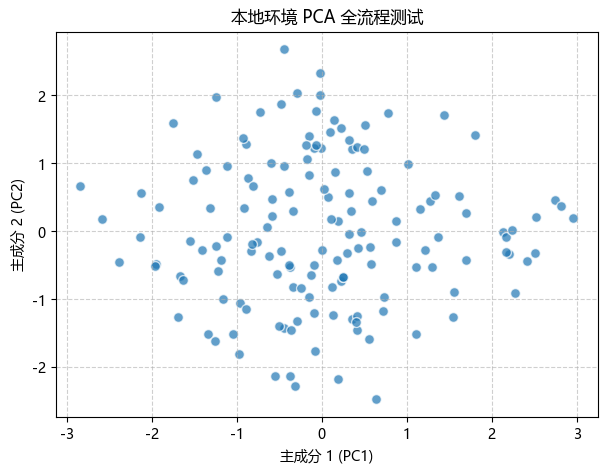

🎉 测试完毕！如果你看到了散点图，说明环境完美运行！


In [1]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# --- 1. 测试 numpy 和 pandas (生成虚拟数据) ---
print("正在生成测试数据...")
np.random.seed(42)
# 假设有 150 个样本，5 个特征
dummy_data = np.random.rand(150, 5)
df = pd.DataFrame(dummy_data, columns=['特征A', '特征B', '特征C', '特征D', '特征E'])
print("数据前 3 行：\n", df.head(3))

# --- 2. 测试 scikit-learn (标准化与 PCA 降维) ---
print("\n正在执行 PCA 降维...")
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df)

# 将 5 维数据降到 2 维
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)
print("降维成功！输出的矩阵形状：", data_pca.shape)

# --- 3. 测试 matplotlib (可视化展示) ---
print("\n正在绘制图表...")

# 💡 Windows 系统专属配置：防止图表里的中文变成方块乱码
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei'] 
plt.rcParams['axes.unicode_minus'] = False 

plt.figure(figsize=(7, 5))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c='#1f77b4', alpha=0.7, edgecolors='white', s=50)
plt.title("本地环境 PCA 全流程测试")
plt.xlabel("主成分 1 (PC1)")
plt.ylabel("主成分 2 (PC2)")
plt.grid(True, linestyle='--', alpha=0.6)

# 显示图表
plt.show()
print("🎉 测试完毕！如果你看到了散点图，说明环境完美运行！")

\\cabinet\data\Public_dataset\cheXpert\CXR8\images

In [2]:
import sys
print("当前运行的 Python 解释器路径：")
print(sys.executable)

print("\n当前环境安装的包列表：")
!pip list

当前运行的 Python 解释器路径：
c:\M1\PCA\X_ray\.venv\Scripts\python.exe

当前环境安装的包列表：
Package                   Version
------------------------- -----------
anyio                     4.13.0
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.3.0
attrs                     26.1.0
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
certifi                   2026.2.25
cffi                      2.0.0
charset-normalizer        3.4.7
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.3
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.2.1
defusedxml                0.7.1
executing                 2.2.1
fastjsonschema            2.21.2
fonttools                 4.62.1
fqdn                      1.5.1
h11                       0.16.0
httpcore                  1.0.9
httpx  

In [1]:
import numpy as np
import torch
import pickle

# 请将这里的路径替换为你电脑上 FVs_medsiglip 文件的实际路径
# 例如： r"C:\Users\YourName\Desktop\FVs_medsiglip" 或者映射的网络盘 r"Z:\derivatives\cheXpert\FVs_medsiglip"
file_path = r"\\cabinet\derivatives\cheXpert\FVs_medsiglip" 

print("开始测试文件格式...\n")

# 1. 测试 Numpy 格式
try:
    print("尝试作为 Numpy 读取...")
    data_np = np.load(file_path, allow_pickle=True)
    print("✅ 成功！这是一个 Numpy 文件。")
    print(f"数据类型: {type(data_np)}, 形状: {getattr(data_np, 'shape', '未知')}")
except Exception as e:
    print(f"❌ 不是 Numpy 格式 ({type(e).__name__})")

print("-" * 30)

# 2. 测试 PyTorch 格式
try:
    print("尝试作为 PyTorch 读取...")
    data_pt = torch.load(file_path, weights_only=False)
    print("✅ 成功！这是一个 PyTorch 文件。")
    print(f"数据类型: {type(data_pt)}, 形状: {getattr(data_pt, 'shape', '未知')}")
except Exception as e:
    print(f"❌ 不是 PyTorch 格式 ({type(e).__name__})")

print("-" * 30)

# 3. 测试 Pickle 格式
try:
    print("尝试作为 Pickle 读取...")
    with open(file_path, 'rb') as f:
        data_pkl = pickle.load(f)
    print("✅ 成功！这是一个 Pickle 文件。")
    print(f"数据类型: {type(data_pkl)}")
    if isinstance(data_pkl, dict):
        print(f"字典包含的键: {list(data_pkl.keys())[:5]} ...")
    elif hasattr(data_pkl, 'shape'):
        print(f"形状: {data_pkl.shape}")
except Exception as e:
    print(f"❌ 不是 Pickle 格式 ({type(e).__name__})")

开始测试文件格式...

尝试作为 Numpy 读取...
✅ 成功！这是一个 Numpy 文件。
数据类型: <class 'numpy.lib.npyio.NpzFile'>, 形状: 未知
------------------------------
尝试作为 PyTorch 读取...
✅ 成功！这是一个 PyTorch 文件。
数据类型: <class 'dict'>, 形状: 未知
------------------------------
尝试作为 Pickle 读取...
❌ 不是 Pickle 格式 (UnpicklingError)
